## Imports

In [63]:
import gc
import os
import itertools
import pickle
import re
import time

import warnings
warnings.filterwarnings('ignore')

from random import choice, choices
from functools import reduce
from tqdm import tqdm
from itertools import cycle

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
%matplotlib inline

from functools import reduce
from tqdm import tqdm
from itertools import cycle
from scipy import stats
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import ensemble
from sklearn import decomposition
from sklearn import tree

import lightgbm as lgb
import xgboost as xgb
from xgboost import callback

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

## Data Loading

In [64]:
pcp_df = pd.read_csv("./power_consumption_prediction.csv")
cl_df = pd.read_csv("./CLdata.csv")
bs_df = pd.read_csv("./BSinfo.csv")
ec_df  = pd.read_csv("./ECdata.csv")
ss_df = pd.read_csv("./SampleSubmission.csv")

pcp_df.shape, cl_df.shape, bs_df.shape, ec_df.shape, ss_df.shape

((26705, 4), (125575, 10), (1217, 8), (92629, 3), (26139, 2))

In [65]:
ec_df.head()

,Time,BS,Energy
0,1/1/2023 1:00,B_0,64.275037
1,1/1/2023 2:00,B_0,55.904335
2,1/1/2023 3:00,B_0,57.698057
3,1/1/2023 4:00,B_0,55.156951
4,1/1/2023 5:00,B_0,56.053812


In [66]:
cl_df.head()

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6
0,1/1/2023 1:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0
1,1/1/2023 2:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0
2,1/1/2023 3:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0
3,1/1/2023 4:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0
4,1/1/2023 5:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0


In [67]:
bs_df.head()

,BS,CellName,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,B_0,Cell0,Type1,Mode2,365.0,20,4,6.875934
1,B_1,Cell0,Type2,Mode2,532.0,20,4,6.875934
2,B_2,Cell0,Type1,Mode2,365.0,20,4,6.875934
3,B_3,Cell0,Type2,Mode2,532.0,20,4,6.875934
4,B_4,Cell0,Type2,Mode2,532.0,20,4,6.875934


In [68]:
pcp_df.head()

,Time,BS,Energy,w
0,1/1/2023 6:00,B_0,NaN,1
1,1/1/2023 11:00,B_0,NaN,1
2,1/1/2023 12:00,B_0,NaN,1
3,1/1/2023 13:00,B_0,NaN,1
4,1/1/2023 23:00,B_0,NaN,1


In [69]:
pcp_df['w'].value_counts()

,count
w,
1,23755
5,2950


## Data Pre-Processing

In [70]:
def rename_columns(df):
    df.rename(columns=lambda x: x.lower().replace(' ', '_'), inplace=True)
    return df

In [71]:
pcp_df = rename_columns(pcp_df)
cl_df = rename_columns(cl_df)
bs_df = rename_columns(bs_df)
ec_df = rename_columns(ec_df)

In [72]:
cl_df.head()

,time,bs,cellname,load,esmode1,esmode2,esmode3,esmode4,esmode5,esmode6
0,1/1/2023 1:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0
1,1/1/2023 2:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0
2,1/1/2023 3:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0
3,1/1/2023 4:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0
4,1/1/2023 5:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0


In [73]:
bs_df.head()

,bs,cellname,rutype,mode,frequency,bandwidth,antennas,txpower
0,B_0,Cell0,Type1,Mode2,365.0,20,4,6.875934
1,B_1,Cell0,Type2,Mode2,532.0,20,4,6.875934
2,B_2,Cell0,Type1,Mode2,365.0,20,4,6.875934
3,B_3,Cell0,Type2,Mode2,532.0,20,4,6.875934
4,B_4,Cell0,Type2,Mode2,532.0,20,4,6.875934


In [74]:
ec_df.head()

,time,bs,energy
0,1/1/2023 1:00,B_0,64.275037
1,1/1/2023 2:00,B_0,55.904335
2,1/1/2023 3:00,B_0,57.698057
3,1/1/2023 4:00,B_0,55.156951
4,1/1/2023 5:00,B_0,56.053812


In [75]:
pcp_df.head()

,time,bs,energy,w
0,1/1/2023 6:00,B_0,NaN,1
1,1/1/2023 11:00,B_0,NaN,1
2,1/1/2023 12:00,B_0,NaN,1
3,1/1/2023 13:00,B_0,NaN,1
4,1/1/2023 23:00,B_0,NaN,1


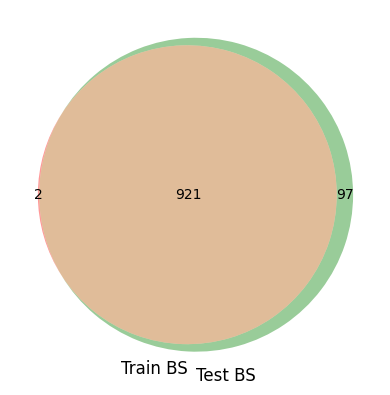

In [76]:
train_bs_set = set(ec_df['bs'].values.tolist())
test_bs_set = set(pcp_df['bs'].values.tolist())

venn2([train_bs_set, test_bs_set], ('Train BS', 'Test BS'))
plt.show()

In [77]:
cl_df['time'] = pd.to_datetime(cl_df['time'])
ec_df['time'] = pd.to_datetime(ec_df['time'])
pcp_df['time'] = pd.to_datetime(pcp_df['time'])

In [78]:
cl_bs_df = cl_df.merge(bs_df, on=['bs', 'cellname'], how='left')
cl_bs_df.head()

,time,bs,cellname,load,esmode1,esmode2,esmode3,esmode4,esmode5,esmode6,rutype,mode,frequency,bandwidth,antennas,txpower
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934


In [79]:
cl_bs_df[cl_bs_df['bs'] == 'B_0']

,time,bs,cellname,load,esmode1,esmode2,esmode3,esmode4,esmode5,esmode6,rutype,mode,frequency,bandwidth,antennas,txpower
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118787,2023-01-02 19:00:00,B_0,Cell1,0.206135,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,426.98,2,4,7.327504
118788,2023-01-02 20:00:00,B_0,Cell1,0.152981,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,426.98,2,4,7.327504
118789,2023-01-02 21:00:00,B_0,Cell1,0.150808,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,426.98,2,4,7.327504
118790,2023-01-02 22:00:00,B_0,Cell1,0.289731,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,426.98,2,4,7.327504


In [80]:
cl_bs_df.groupby("bs")['cellname'].nunique()

,cellname
bs,
B_0,2
B_1,1
B_10,2
B_100,1
B_1000,1
...,...
B_995,1
B_996,1
B_997,1


In [81]:
cl_bs_df.groupby("bs")['cellname'].nunique().value_counts()

,count
cellname,
1,827
2,191
4,2


In [82]:
ec_df.head()

,time,bs,energy
0,2023-01-01 01:00:00,B_0,64.275037
1,2023-01-01 02:00:00,B_0,55.904335
2,2023-01-01 03:00:00,B_0,57.698057
3,2023-01-01 04:00:00,B_0,55.156951
4,2023-01-01 05:00:00,B_0,56.053812


In [83]:
cl_bs_df = cl_bs_df.pivot(
    index=['time', 'bs'],
    columns=['cellname'],
    values=['load', 'esmode1', 'esmode2', 'esmode3',
       'esmode4', 'esmode5', 'esmode6', 'frequency',
       'bandwidth', 'antennas', 'txpower'],
).reset_index()

cl_bs_df.columns = ['_'.join([str(i) for i in x]) for x in cl_bs_df.columns]
cl_bs_df.columns = cl_bs_df.columns.str.strip('_')
cl_bs_df = rename_columns(cl_bs_df)
cl_bs_df = cl_bs_df.merge(bs_df.groupby('bs')[['rutype', 'mode']].first().reset_index(), on='bs', how='left')

In [84]:
cl_bs_df.head()

,time,bs,load_cell0,load_cell1,load_cell2,load_cell3,esmode1_cell0,esmode1_cell1,esmode1_cell2,esmode1_cell3,esmode2_cell0,esmode2_cell1,esmode2_cell2,esmode2_cell3,esmode3_cell0,esmode3_cell1,esmode3_cell2,esmode3_cell3,esmode4_cell0,esmode4_cell1,esmode4_cell2,esmode4_cell3,esmode5_cell0,esmode5_cell1,esmode5_cell2,esmode5_cell3,esmode6_cell0,esmode6_cell1,esmode6_cell2,esmode6_cell3,frequency_cell0,frequency_cell1,frequency_cell2,frequency_cell3,bandwidth_cell0,bandwidth_cell1,bandwidth_cell2,bandwidth_cell3,antennas_cell0,antennas_cell1,antennas_cell2,antennas_cell3,txpower_cell0,txpower_cell1,txpower_cell2,txpower_cell3,rutype,mode
0,2023-01-01 01:00:00,B_0,0.487936,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,365.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type1,Mode2
1,2023-01-01 01:00:00,B_1,0.034770,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type2,Mode2
2,2023-01-01 01:00:00,B_10,0.010457,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,365.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type1,Mode2
3,2023-01-01 01:00:00,B_100,0.011220,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type4,Mode2
4,2023-01-01 01:00:00,B_101,0.008720,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type4,Mode2


In [85]:
cl_bs_df.describe()

,time,load_cell0,load_cell1,load_cell2,load_cell3,esmode1_cell0,esmode1_cell1,esmode1_cell2,esmode1_cell3,esmode2_cell0,esmode2_cell1,esmode2_cell2,esmode2_cell3,esmode3_cell0,esmode3_cell1,esmode3_cell2,esmode3_cell3,esmode4_cell0,esmode4_cell1,esmode4_cell2,esmode4_cell3,esmode5_cell0,esmode5_cell1,esmode5_cell2,esmode5_cell3,esmode6_cell0,esmode6_cell1,esmode6_cell2,esmode6_cell3,frequency_cell0,frequency_cell1,frequency_cell2,frequency_cell3,bandwidth_cell0,bandwidth_cell1,bandwidth_cell2,bandwidth_cell3,antennas_cell0,antennas_cell1,antennas_cell2,antennas_cell3,txpower_cell0,txpower_cell1,txpower_cell2,txpower_cell3
count,118768,118768.000000,6711.000000,48.000000,48.000000,118768.000000,6711.000000,48.0,48.0,118768.000000,6711.000000,48.0,48.0,118768.000000,6711.000000,48.0,48.0,118768.0,6711.0,48.0,48.0,118768.000000,6711.0,48.0,48.0,118768.000000,6711.000000,48.0,48.0,118768.000000,6711.000000,4.800000e+01,4.800000e+01,118768.000000,6711.000000,48.0,48.0,118768.000000,6711.000000,48.0,48.0,118768.000000,6711.000000,48.000000,48.000000
mean,2023-01-03 23:54:54.281287680,0.246362,0.111214,0.070212,0.081115,0.042145,0.004985,0.0,0.0,0.038640,0.003311,0.0,0.0,0.000082,0.000135,0.0,0.0,0.0,0.0,0.0,0.0,0.000012,0.0,0.0,0.0,0.019168,0.386253,0.0,0.0,373.152776,379.542459,4.269800e+02,4.269800e+02,16.323740,6.338251,2.0,2.0,2.493079,2.218149,2.0,2.0,6.728786,7.028953,6.877429,6.877429
min,2023-01-01 01:00:00,0.000000,0.008190,0.045942,0.045904,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,155.600000,155.600000,4.269800e+02,4.269800e+02,2.000000,2.000000,2.0,2.0,1.000000,1.000000,2.0,2.0,5.381166,6.427504,6.877429,6.877429
25%,2023-01-02 10:00:00,0.055714,0.051894,0.054442,0.051822,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,189.000000,365.000000,4.269800e+02,4.269800e+02,10.000000,2.000000,2.0,2.0,2.000000,2.000000,2.0,2.0,6.427504,6.761584,6.877429,6.877429
50%,2023-01-03 19:00:00,0.162470,0.079423,0.066760,0.067856,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.275973,0.0,0.0,365.000000,426.980000,4.269800e+02,4.269800e+02,20.000000,2.000000,2.0,2.0,2.000000,2.000000,2.0,2.0,6.875934,7.325859,6.877429,6.877429
75%,2023-01-05 13:00:00,0.367142,0.138202,0.079385,0.095495,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.803992,0.0,0.0,532.000000,426.980000,4.269800e+02,4.269800e+02,20.000000,10.000000,2.0,2.0,2.000000,2.000000,2.0,2.0,6.875934,7.325859,6.877429,6.877429
max,2023-01-08 00:00:00,0.993957,0.891770,0.174846,0.196519,1.000000,1.000000,0.0,0.0,1.000000,1.000000,0.0,0.0,0.154563,0.062805,0.0,0.0,0.0,0.0,0.0,0.0,0.768070,0.0,0.0,0.0,0.931032,0.927924,0.0,0.0,979.998000,697.002000,4.269800e+02,4.269800e+02,20.000000,20.000000,2.0,2.0,64.000000,8.000000,2.0,2.0,8.375336,7.877728,6.877429,6.877429
std,NaN,0.239354,0.091569,0.023807,0.038373,0.194184,0.064911,0.0,0.0,0.186785,0.052831,0.0,0.0,0.002439,0.002422,0.0,0.0,0.0,0.0,0.0,0.0,0.002882,0.0,0.0,0.0,0.112214,0.395205,0.0,0.0,145.409519,102.348829,2.872248e-13,2.872248e-13,5.238965,6.209317,0.0,0.0,4.617650,0.755766,0.0,0.0,0.330830,0.386024,0.000000,0.000000


In [86]:
ec_df.head()

,time,bs,energy
0,2023-01-01 01:00:00,B_0,64.275037
1,2023-01-01 02:00:00,B_0,55.904335
2,2023-01-01 03:00:00,B_0,57.698057
3,2023-01-01 04:00:00,B_0,55.156951
4,2023-01-01 05:00:00,B_0,56.053812


In [87]:
df = cl_bs_df.merge(ec_df, on=['time', 'bs'], how='left')

In [88]:
df.head()

,time,bs,load_cell0,load_cell1,load_cell2,load_cell3,esmode1_cell0,esmode1_cell1,esmode1_cell2,esmode1_cell3,esmode2_cell0,esmode2_cell1,esmode2_cell2,esmode2_cell3,esmode3_cell0,esmode3_cell1,esmode3_cell2,esmode3_cell3,esmode4_cell0,esmode4_cell1,esmode4_cell2,esmode4_cell3,esmode5_cell0,esmode5_cell1,esmode5_cell2,esmode5_cell3,esmode6_cell0,esmode6_cell1,esmode6_cell2,esmode6_cell3,frequency_cell0,frequency_cell1,frequency_cell2,frequency_cell3,bandwidth_cell0,bandwidth_cell1,bandwidth_cell2,bandwidth_cell3,antennas_cell0,antennas_cell1,antennas_cell2,antennas_cell3,txpower_cell0,txpower_cell1,txpower_cell2,txpower_cell3,rutype,mode,energy
0,2023-01-01 01:00:00,B_0,0.487936,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,365.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type1,Mode2,64.275037
1,2023-01-01 01:00:00,B_1,0.034770,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type2,Mode2,18.086697
2,2023-01-01 01:00:00,B_10,0.010457,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,365.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type1,Mode2,30.343797
3,2023-01-01 01:00:00,B_100,0.011220,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type4,Mode2,NaN
4,2023-01-01 01:00:00,B_101,0.008720,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type4,Mode2,15.545590


In [89]:
df['energy'].isna().value_counts()

,count
energy,
False,92629
True,26139


In [90]:
df['split'] = df['energy'].isna().apply(lambda x: 'test' if x == True else 'train')

In [91]:
ss_df.shape

(26139, 2)

In [92]:
ec_df.shape

(92629, 3)

## EDA

In [93]:
df['energy'].describe()

,energy
count,92629.000000
mean,28.138997
std,13.934645
min,0.747384
25%,18.236173
50%,24.065770
75%,35.724963
max,100.000000


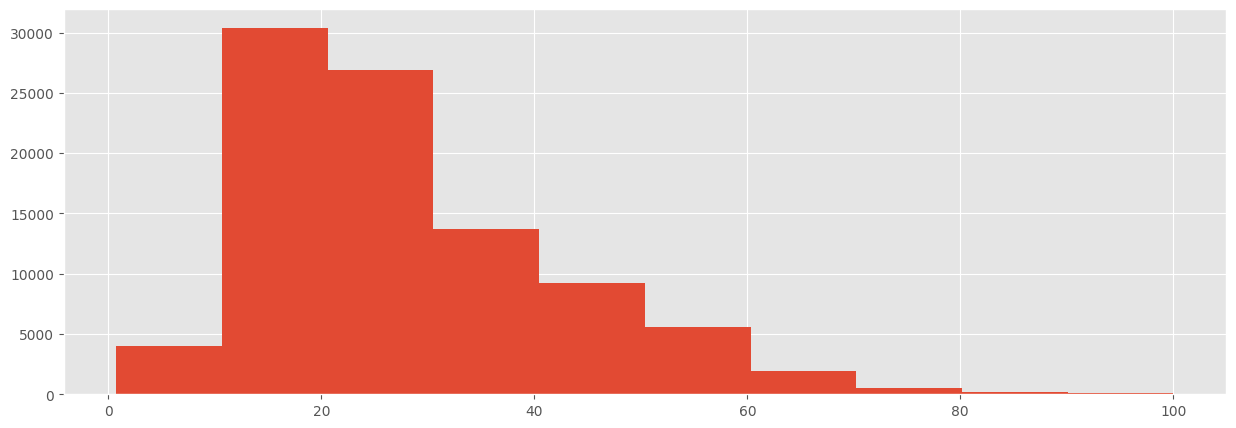

In [94]:
plt.figure(figsize=(15, 5))
df['energy'].hist()
plt.show()

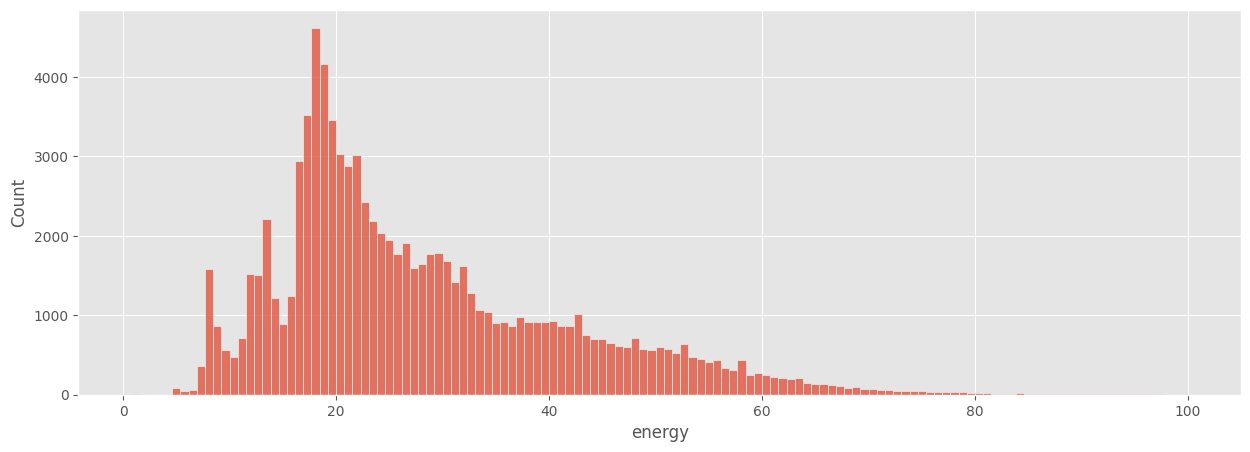

In [95]:
plt.figure(figsize=(15, 5))
sns.histplot(df['energy'])
plt.show()

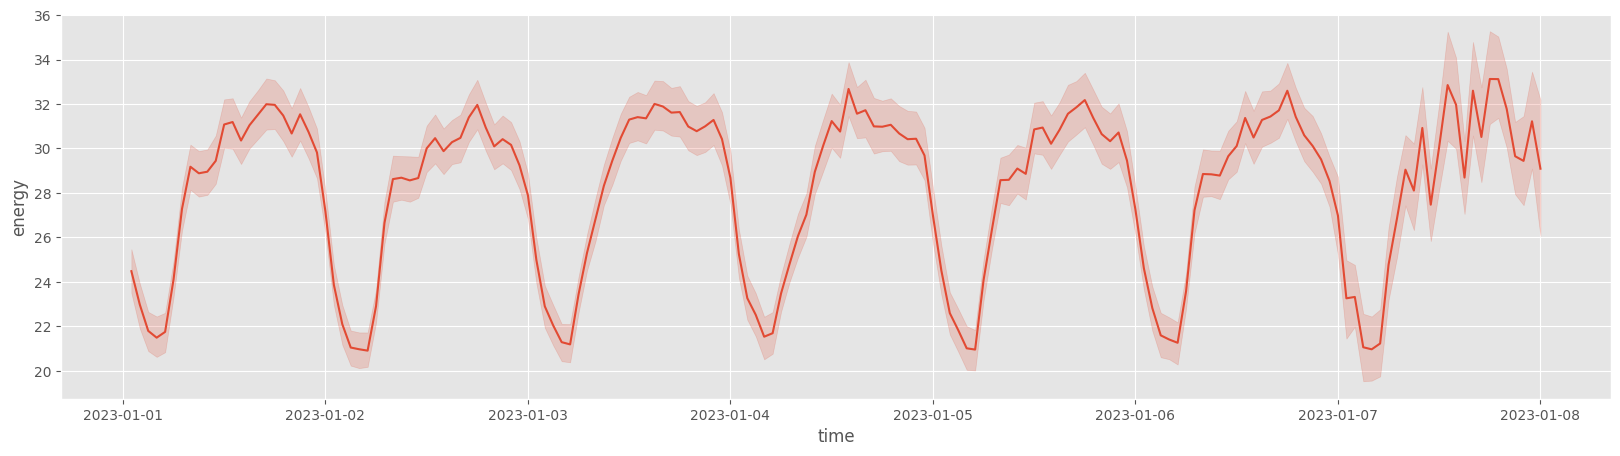

In [96]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x='time', y='energy')
plt.show()

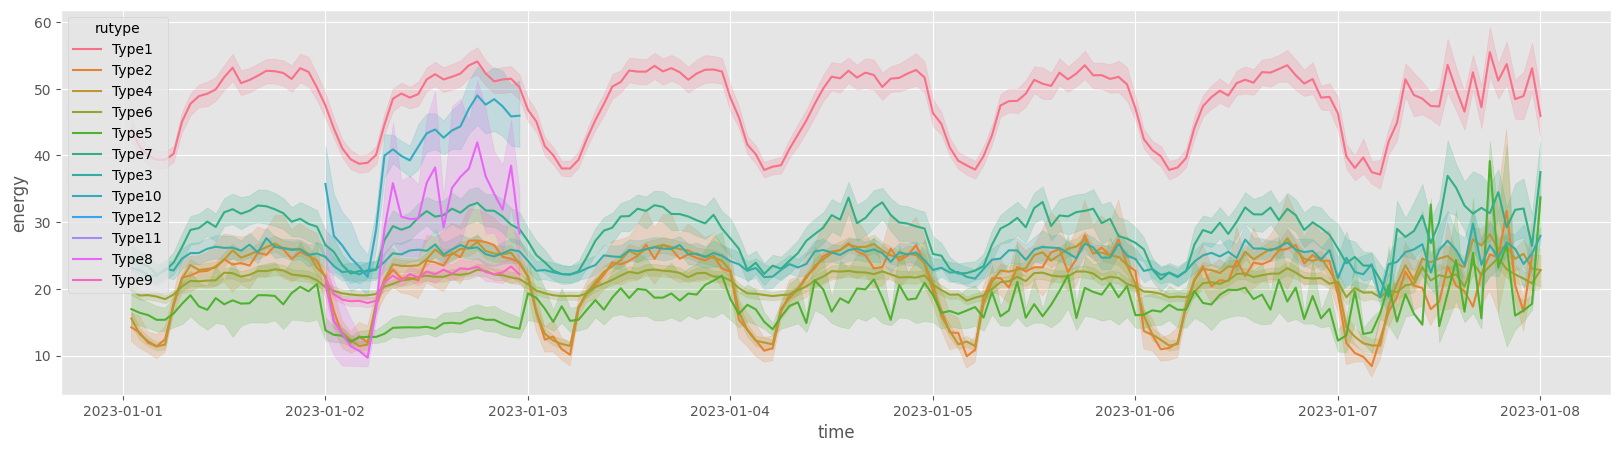

In [97]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x='time', y='energy', hue='rutype')
plt.show()

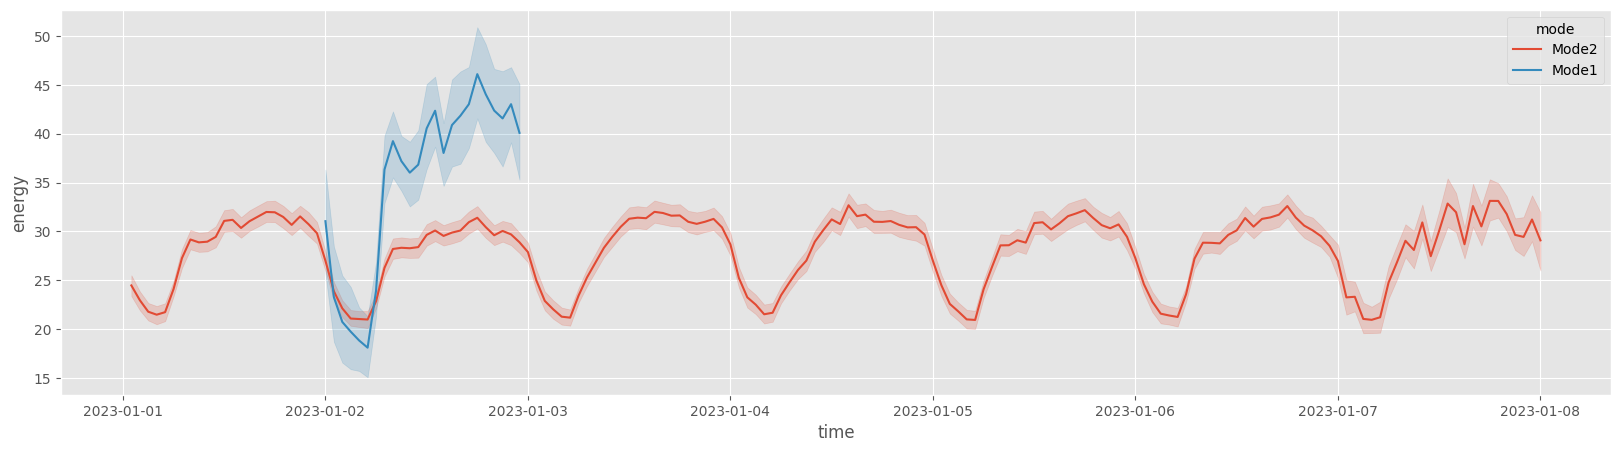

In [98]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x='time', y='energy', hue='mode')
plt.show()

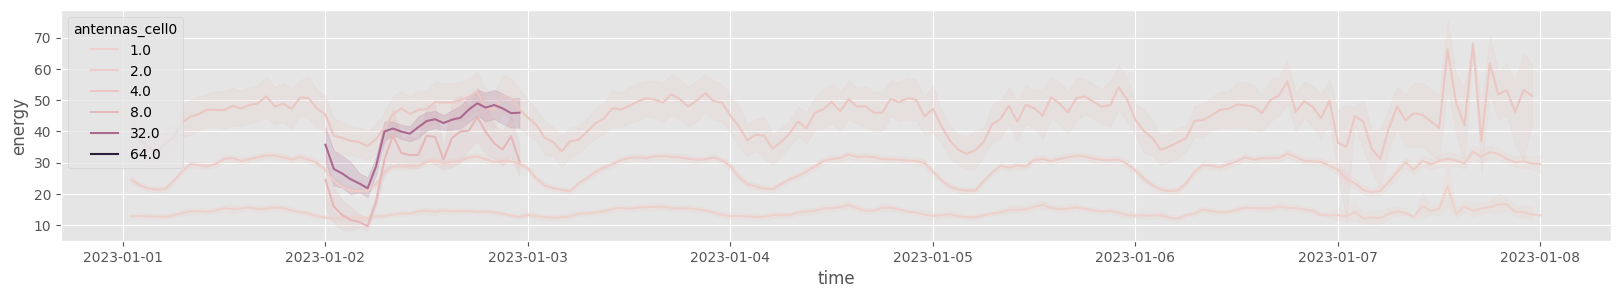

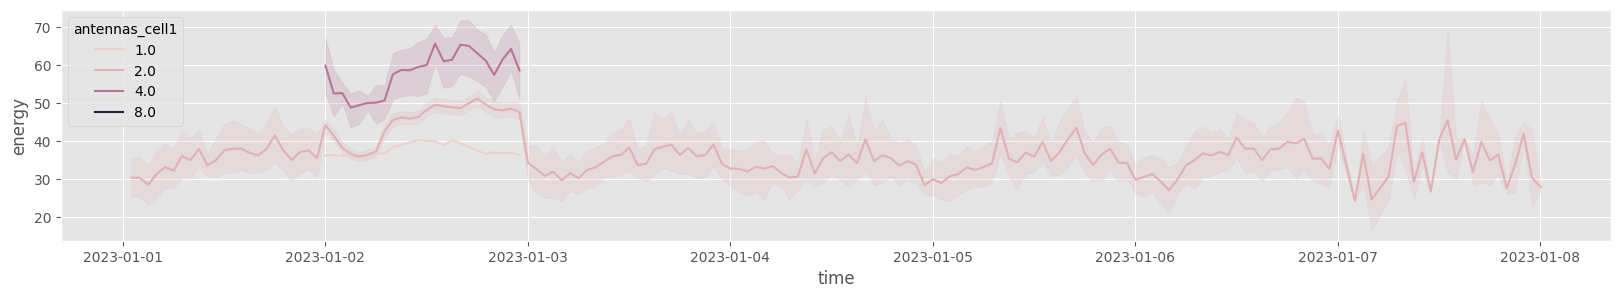

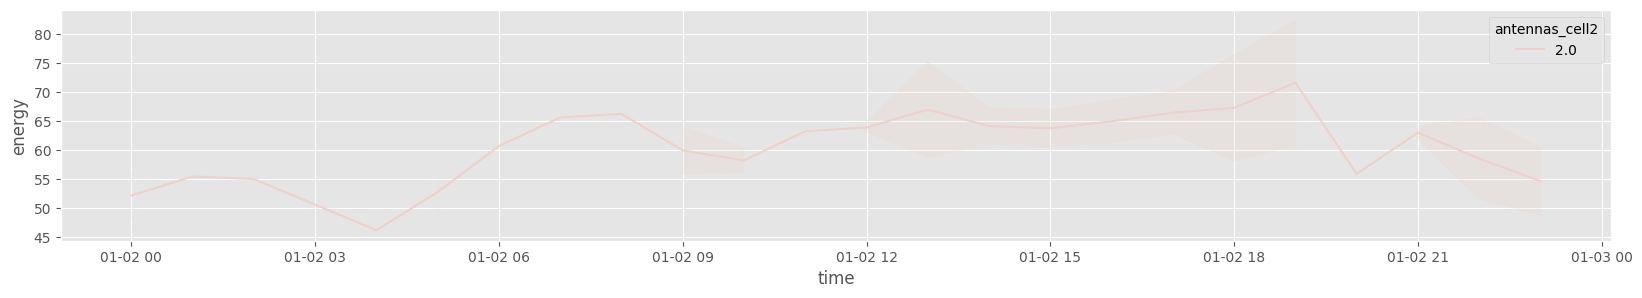

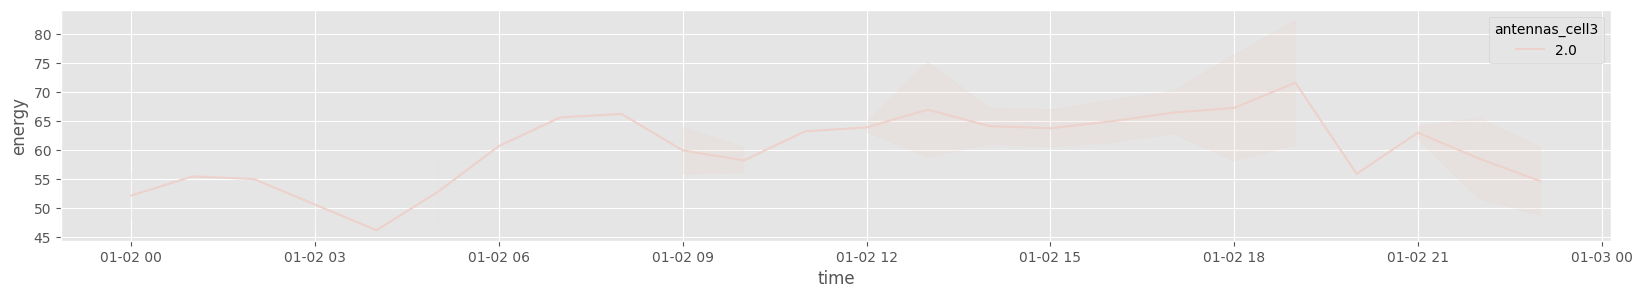

In [99]:
plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='antennas_cell0')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='antennas_cell1')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='antennas_cell2')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='antennas_cell3')
plt.show()

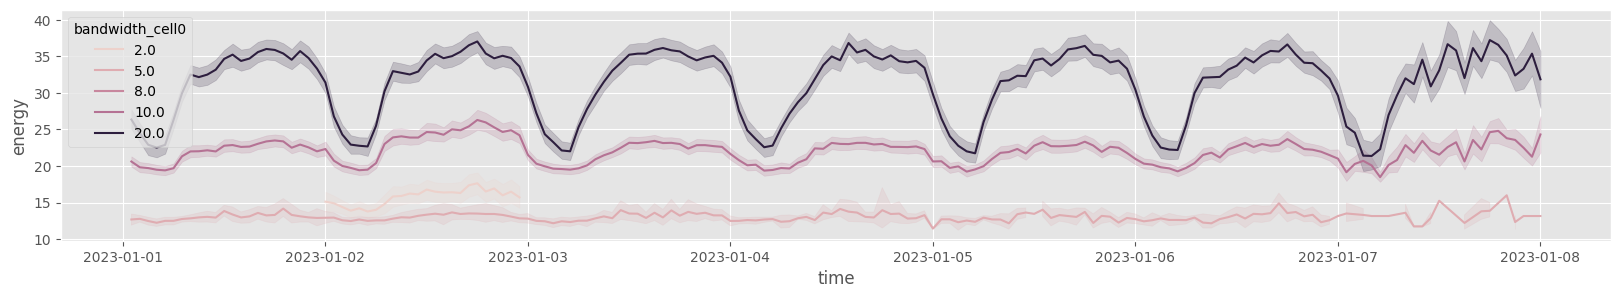

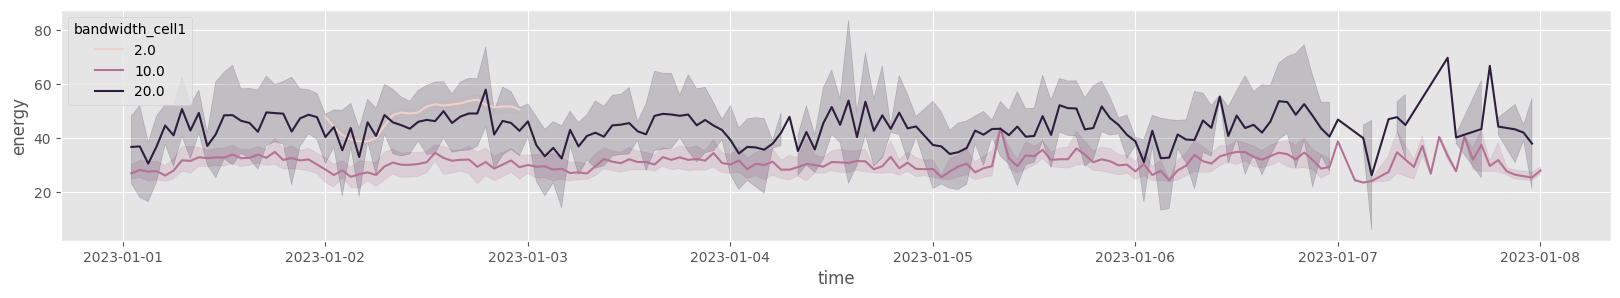

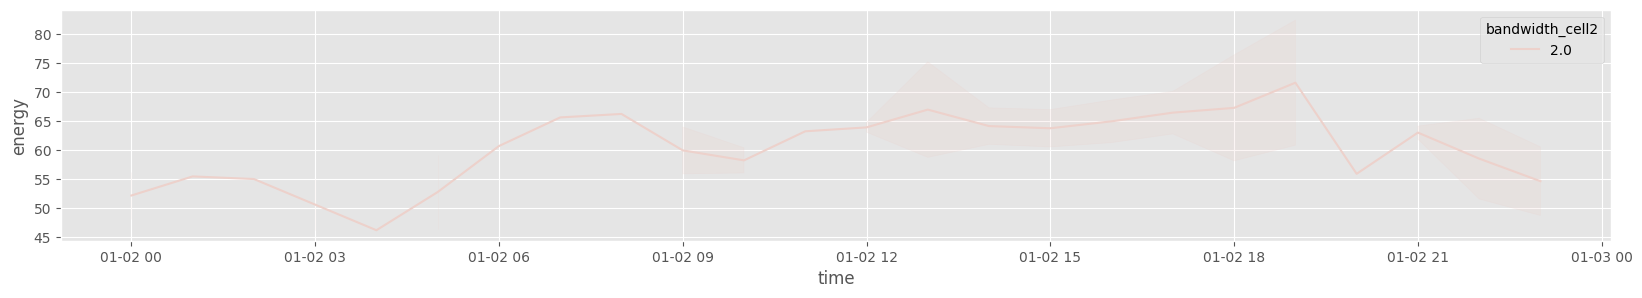

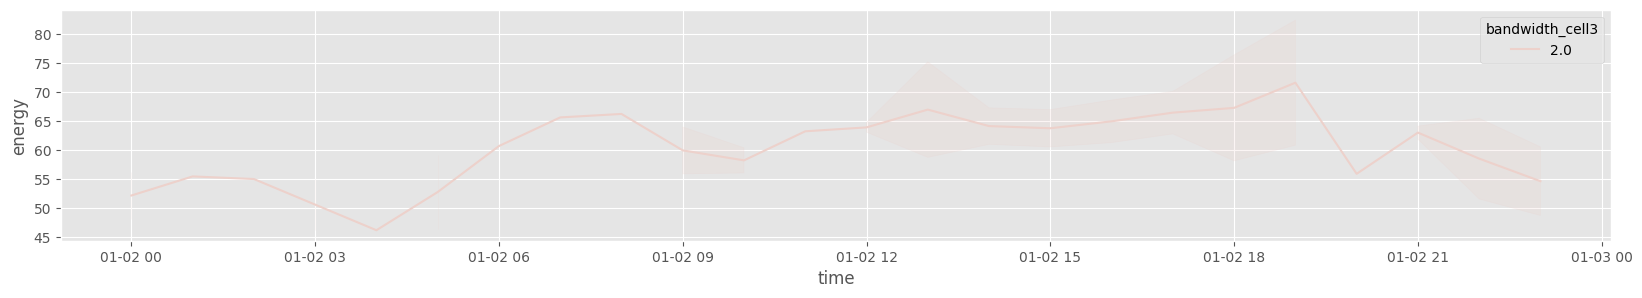

In [100]:
plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='bandwidth_cell0')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='bandwidth_cell1')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='bandwidth_cell2')
plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=df, x='time', y='energy', hue='bandwidth_cell3')
plt.show()

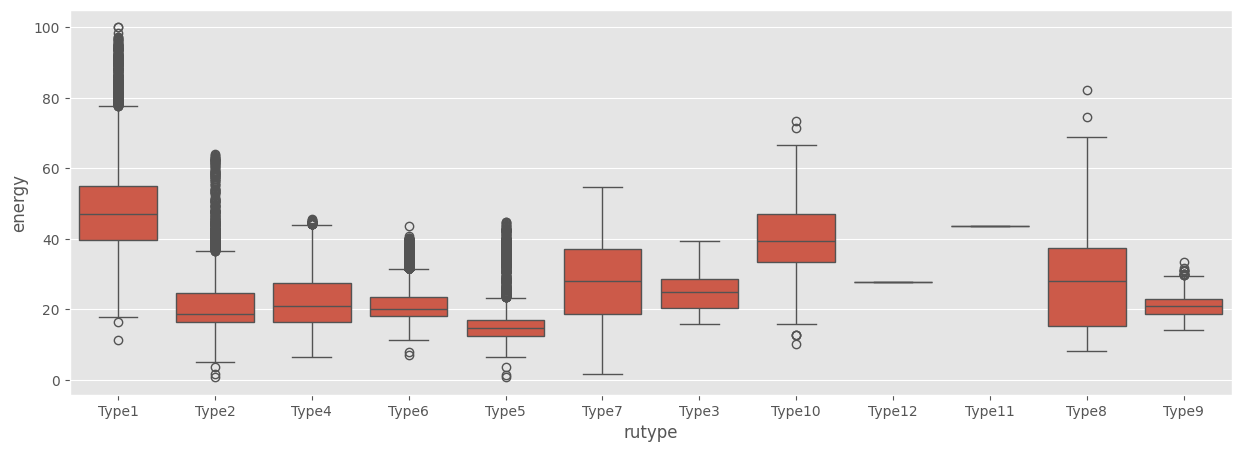

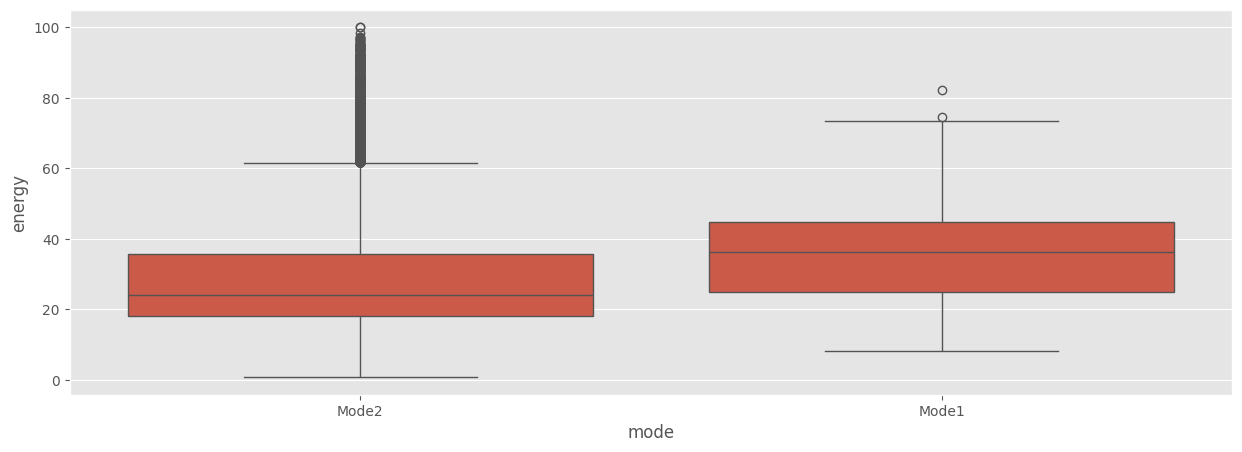

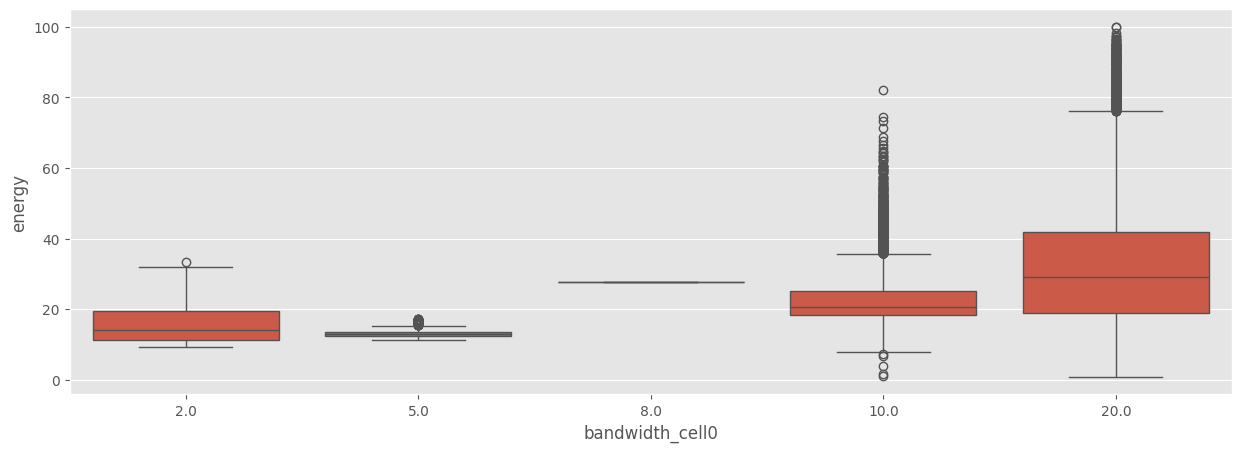

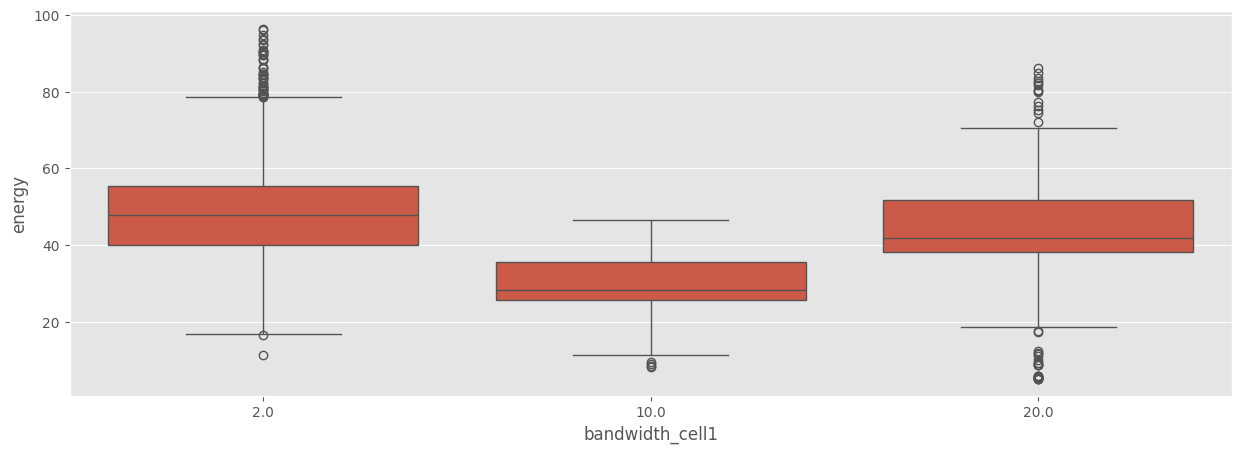

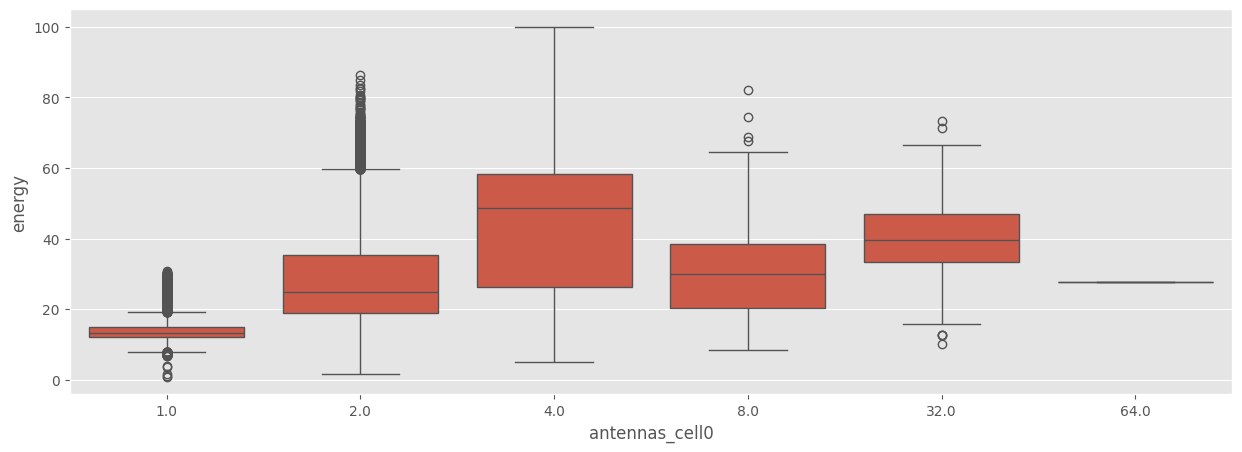

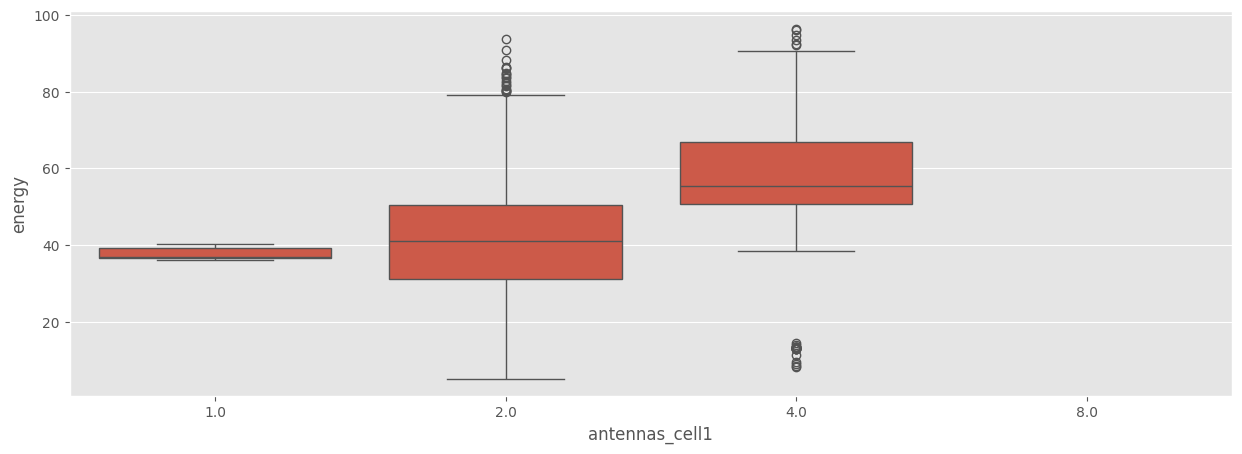

In [101]:
for fe in ['rutype', 'mode', 'bandwidth_cell0', 'bandwidth_cell1', 'antennas_cell0', 'antennas_cell1']:
    plt.figure(figsize=(15, 5))
    sns.boxplot(data=df, x=fe, y='energy')
    plt.show()

In [102]:
def plot_cat_train_test_dist(df, fe_name, hue='split'):

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Plot the distribution plot on the first subplot
    sns.countplot(data=df[df['split'] == 'train'], ax=axes[0], x=fe_name)
    axes[0].set_title('Train Count Plot')

    # Plot the box plot on the second subplot
    sns.countplot(data=df[df['split'] == 'test'], ax=axes[1], x=fe_name)
    axes[1].set_title('Test Count Plot')

    sns.countplot(data=df, ax=axes[2], x=fe_name, hue='split')
    axes[2].set_title('Train & Test Count Plot')

    plt.show()

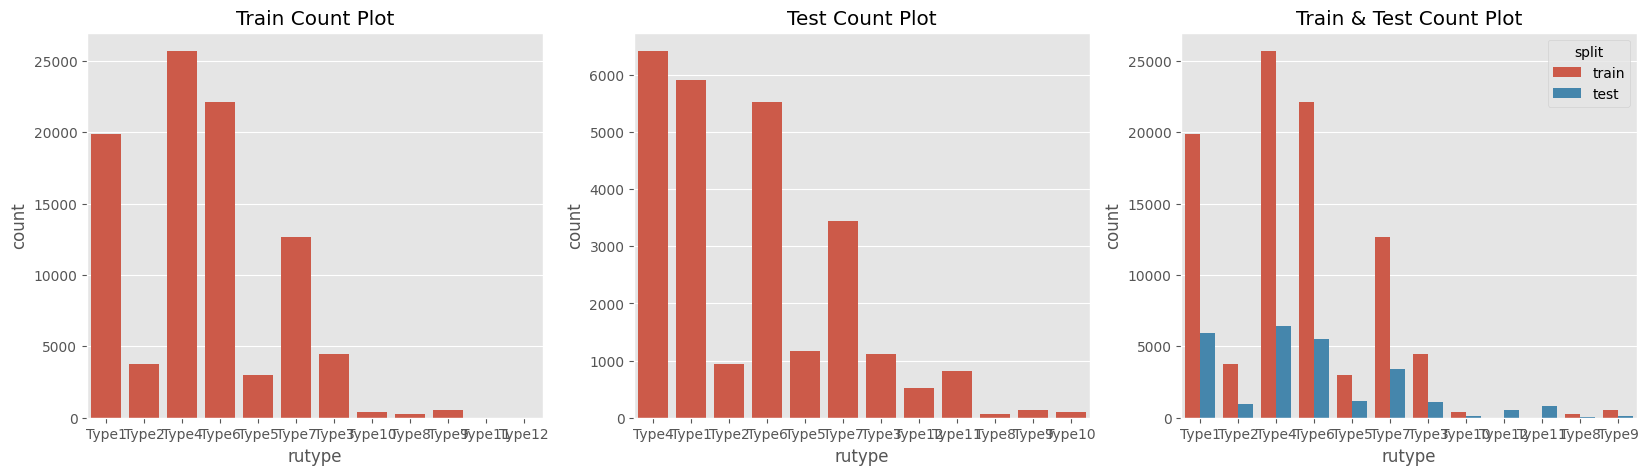

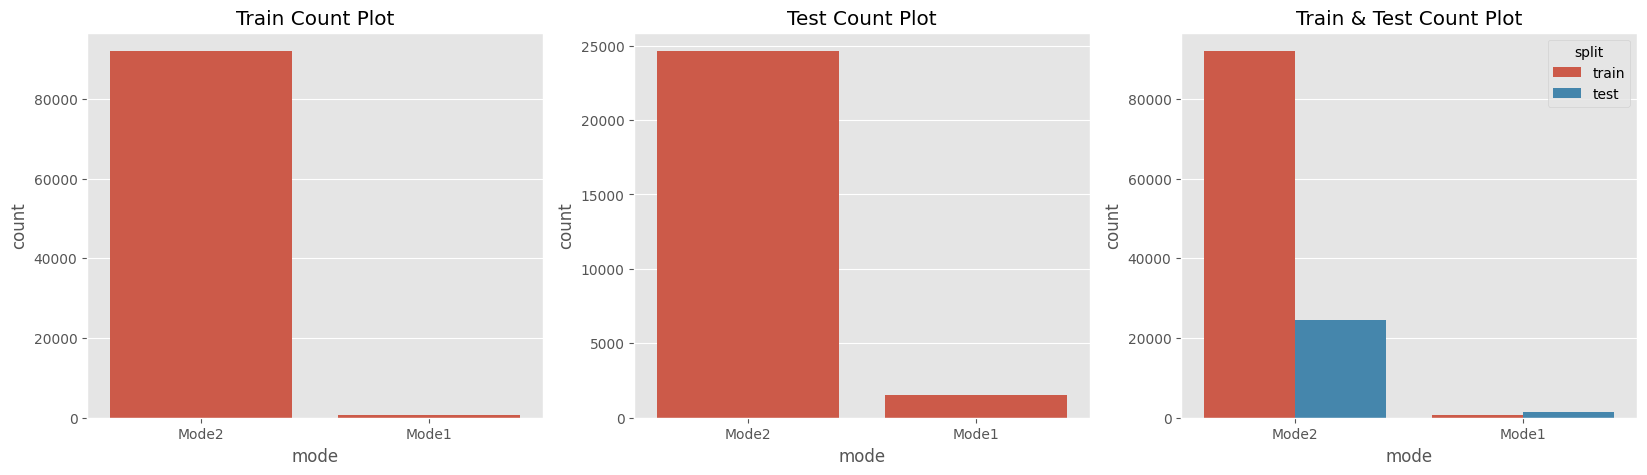

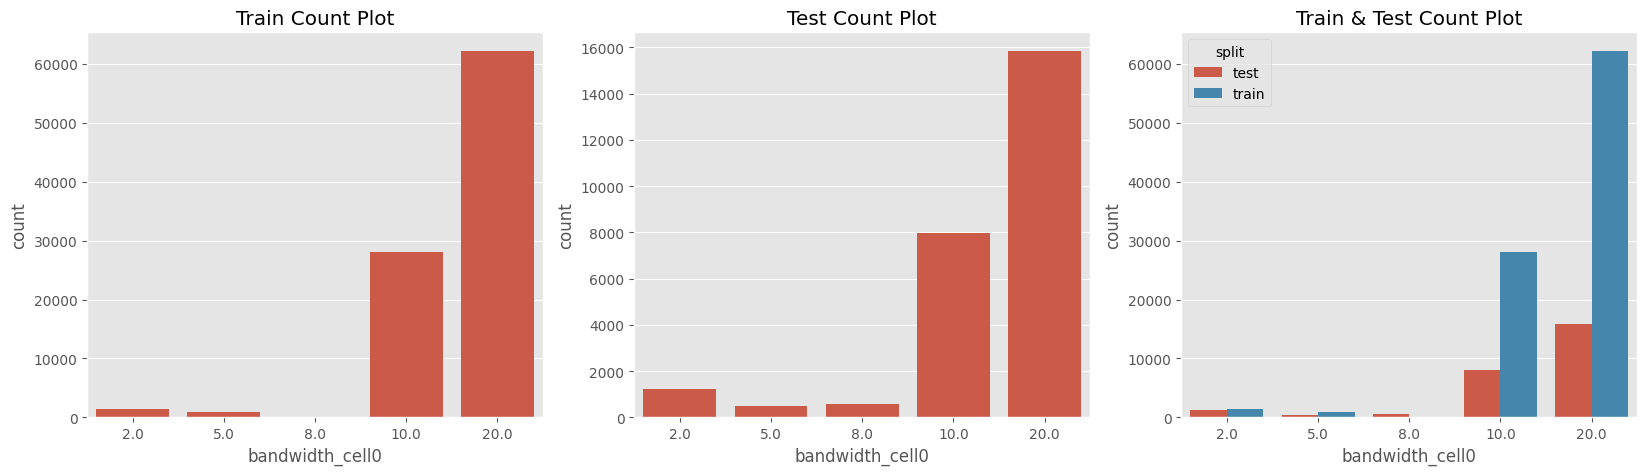

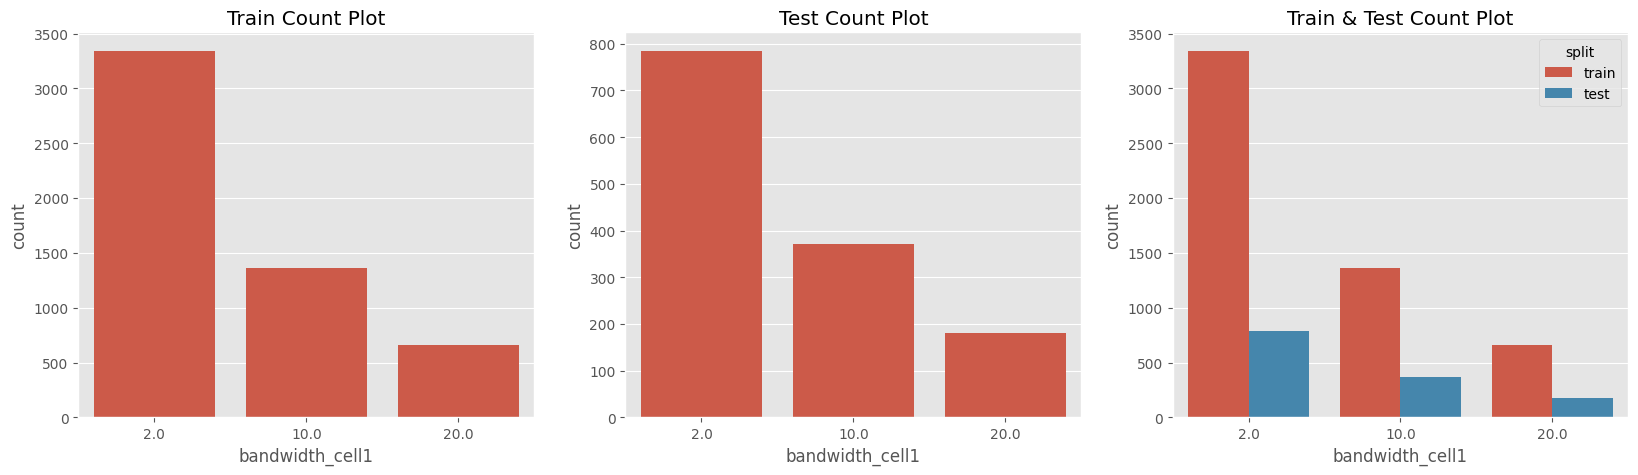

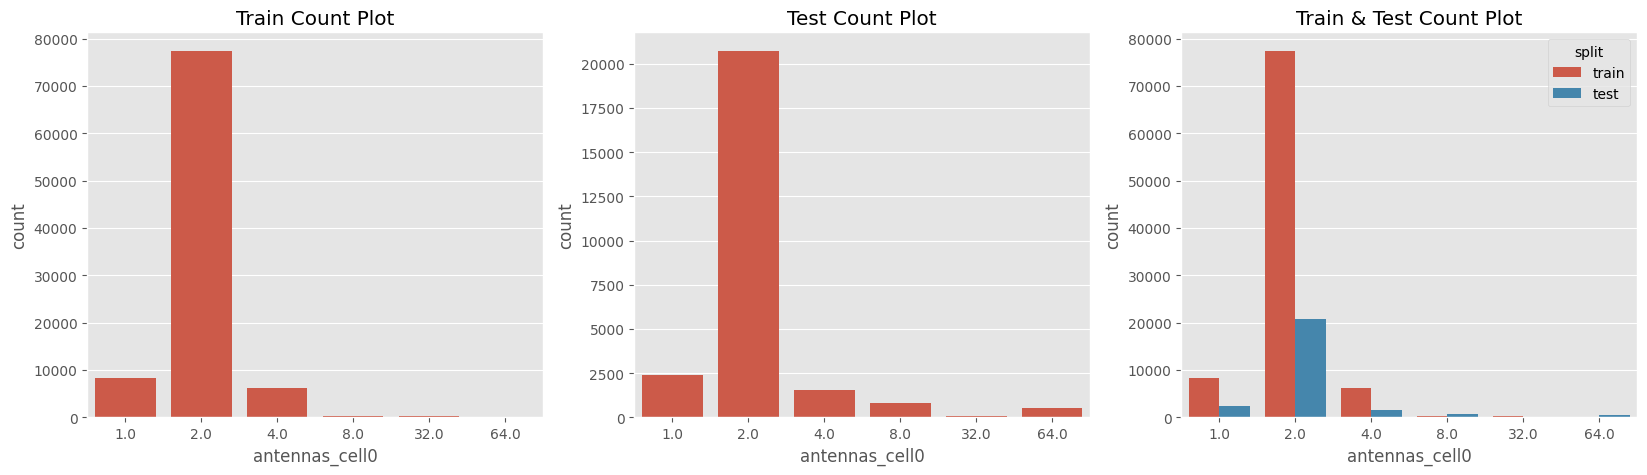

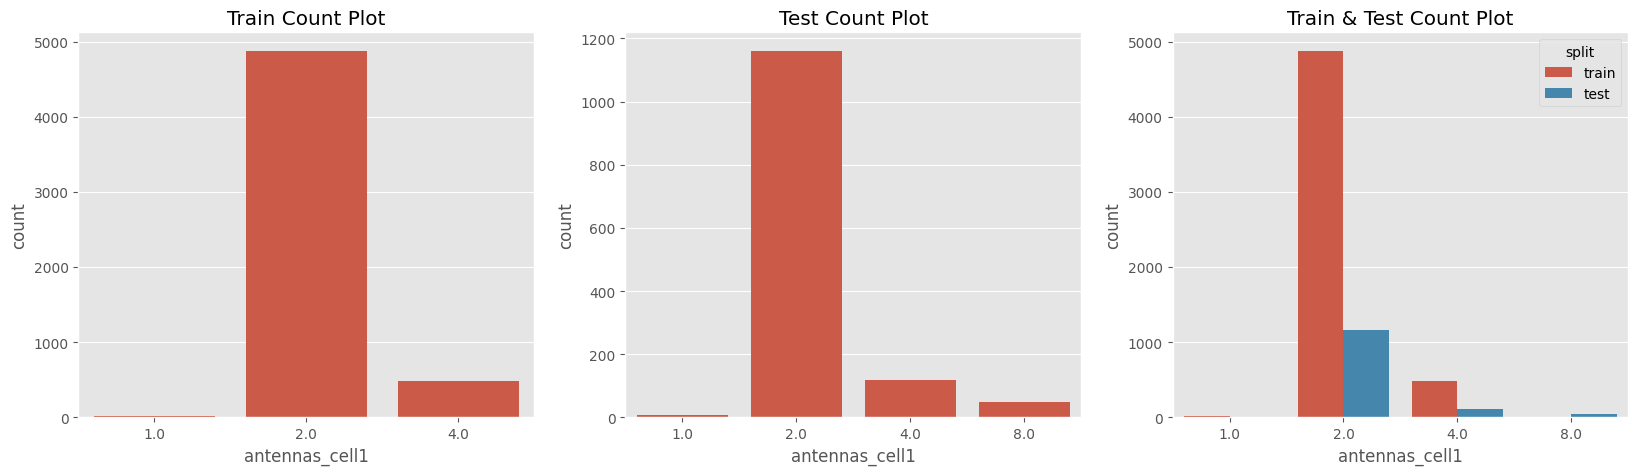

In [103]:
for fe in ['rutype', 'mode', 'bandwidth_cell0', 'bandwidth_cell1', 'antennas_cell0', 'antennas_cell1']:
    plot_cat_train_test_dist(df=df, fe_name=fe, hue='split')

In [104]:
df.groupby("split")['rutype'].value_counts().sort_index()

split  rutype
test   Type1      5908
       Type10      101
       Type11      815
       Type12      527
       Type2       939
       Type3      1111
       Type4      6419
       Type5      1164
       Type6      5521
       Type7      3446
       Type8        58
       Type9       130
train  Type1     19902
       Type10      403
       Type11        1
       Type12        1
       Type2      3757
       Type3      4442
       Type4     25677
       Type5      2974
       Type6     22083
       Type7     12641
       Type8       230
       Type9       518
Name: count, dtype: int64

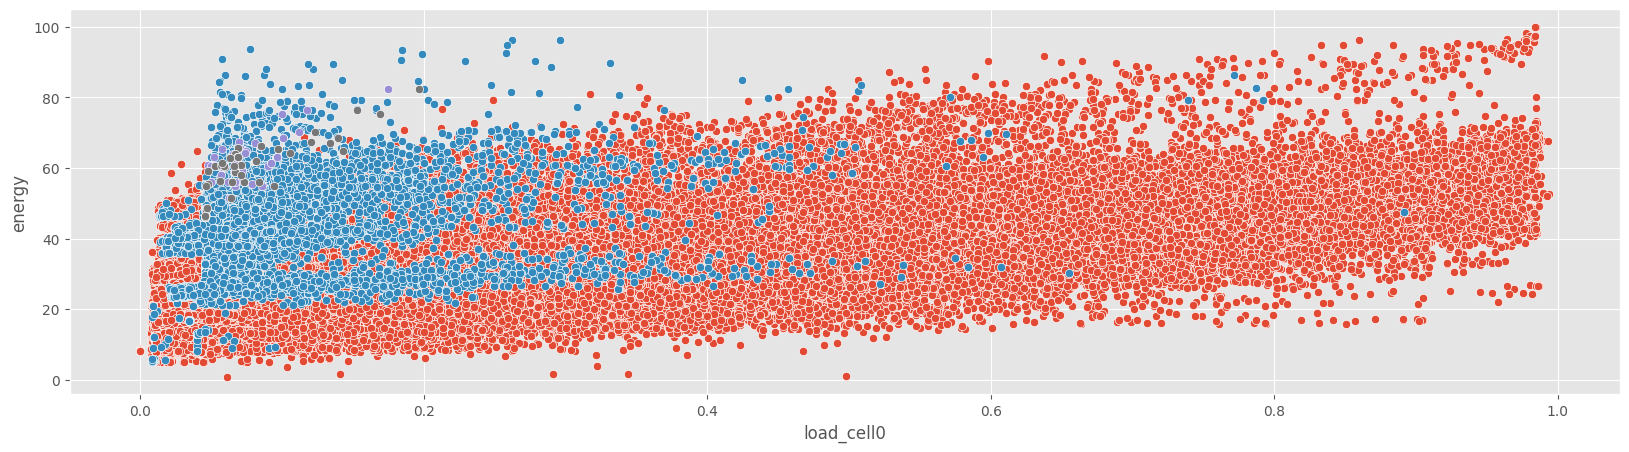

In [105]:
plt.figure(figsize=(20, 5))
sns.scatterplot(data=df[df['split'] == 'train'], x='load_cell0', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='load_cell1', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='load_cell2', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='load_cell3', y='energy')
plt.show()

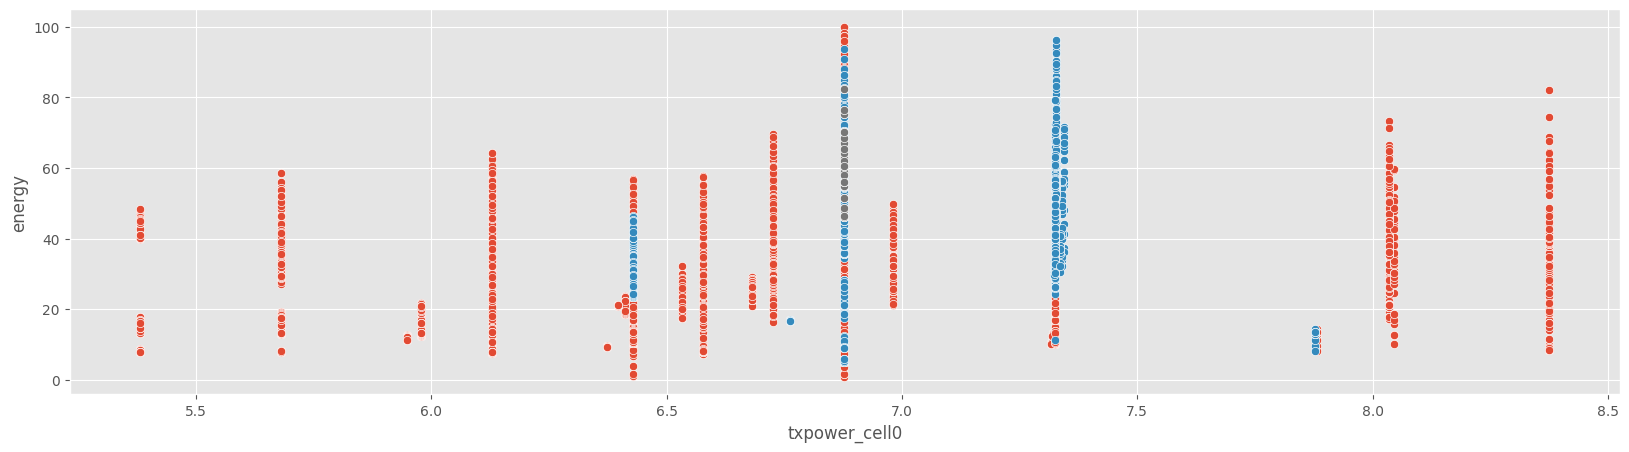

In [106]:
plt.figure(figsize=(20, 5))
sns.scatterplot(data=df[df['split'] == 'train'], x='txpower_cell0', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='txpower_cell1', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='txpower_cell2', y='energy')
sns.scatterplot(data=df[df['split'] == 'train'], x='txpower_cell3', y='energy')
plt.show()

## Modeling

In [107]:
train_data = df[df['split'] =='train']
test_data = df[df['split'] =='test']

train_data.shape, test_data.shape

((92629, 50), (26139, 50))

In [113]:
def feature_engineering(train_df, valid_df, test_df):

    train_df['hour'] = train_df['time'].dt.hour
    valid_df['hour'] = valid_df['time'].dt.hour
    test_df['hour'] = test_df['time'].dt.hour

    # target_encoder = TargetEncoder(min_samples_leaf=1)
    # train_df[['te_rutype', 'te_mode', 'te_hour', 'te_bs']] = target_encoder.fit_transform(X=train_df[['rutype', 'mode', 'hour', 'bs']], y=train_df['energy'])
    # valid_df[['te_rutype', 'te_mode', 'te_hour', 'te_bs']] = target_encoder.transform(X=valid_df[['rutype', 'mode', 'hour', 'bs']])
    # test_df[['te_rutype', 'te_mode', 'te_hour', 'te_bs']] = target_encoder.transform(X=test_df[['rutype', 'mode', 'hour', 'bs']])

    train_df['split'] = 'train'
    valid_df['split'] = 'valid'
    test_df['split'] = 'test'

    df = pd.concat([train_df, valid_df, test_df])
    df['bs_en'] = df['bs'].apply(lambda x: int(x.strip('B_')))

    # df['rutype'] = df['rutype'].apply(lambda x: int(x.strip('Type')))
    # df['mode'] = df['mode'].apply(lambda x: int(x.strip('Mode')))

    df = pd.get_dummies(df, columns=['rutype',  'mode', 'hour'])

    df.sort_values(['time', 'bs'], inplace=True)
    # for fe in ['antennas_cell0', 'antennas_cell1', 'antennas_cell2', 'antennas_cell3', 'load_cell0', 'load_cell1',
    #    'load_cell2', 'load_cell3', 'txpower_cell0', 'txpower_cell1', 'txpower_cell2', 'txpower_cell3']:
    #     for r in [3, 5, 8, 10, 15]:
    #         df[f'r{r}_mean_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).mean())
    #         df[f'r{r}_std_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).std())
    #         df[f'r{r}_skew_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).skew())
    #         df[f'r{r}_max_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).max())

    # Target rolling
    # for fe in ['energy']:
    #     for r in [3, 5, 8, 10, 15]:
    #         df[f'r{r}_mean_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).mean().shift(1))
    #         df[f'r{r}_std_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).std().shift(1))
    #         df[f'r{r}_skew_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).skew().shift(1))
    #         df[f'r{r}_max_{fe}'] = df.groupby(['bs'])[f'{fe}'].transform(lambda x: x.rolling(r, min_periods=1).max().shift(1))


    train_df = df[df['split'] =='train']
    valid_df = df[df['split'] =='valid']
    test_df = df[df['split'] =='test']

    return train_df, valid_df, test_df

In [115]:
target_col = 'energy'
drop_cols = ['time', 'bs', 'split', target_col]

In [116]:
kf = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
kf = kf.split(train_data)

oof_valid_preds = np.zeros(train_data.shape[0], )
test_preds_list = []

for i, (train_idx, valid_idx) in enumerate(kf):

    train_df = train_data.iloc[train_idx]
    valid_df = train_data.iloc[valid_idx]
    test_df = test_data.copy()

    train_df, valid_df, test_df = feature_engineering(
        train_df=train_df,
        valid_df=valid_df,
        test_df=test_df
    )

    train_cols = [col for col in train_df.columns if col not in drop_cols]

    X_train, y_train = train_df[train_cols], train_df[target_col]
    X_valid, y_valid = valid_df[train_cols], valid_df[target_col]
    X_test = test_df[train_cols]

    params = {
        'objective': 'reg:squarederror',
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 10000,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'n_jobs': -1,
        'eval_metric': 'mae',
        'early_stopping_rounds': 100
    }

    model = xgb.XGBRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=100
    )

    valid_preds = model.predict(
        X_valid,
        iteration_range=(0, model.best_iteration + 1)
    )

    test_preds = model.predict(
        X_test,
        iteration_range=(0, model.best_iteration + 1)
    )

    val_score = metrics.mean_absolute_error(y_valid, valid_preds)

    oof_valid_preds[valid_idx] = valid_preds
    test_preds_list.append(test_preds)

    print("=*" * 50)
    print(f"Fold : {i}")
    print(f"Valid score : {val_score}")

oof_score = metrics.mean_absolute_error(train_data[target_col], oof_valid_preds)

final_test_preds = np.mean(test_preds_list, axis=0)

print("_-*" * 50)
print(f"OOF score : {oof_score}")

[0]	validation_0-mae:10.65218
[100]	validation_0-mae:2.38595
[200]	validation_0-mae:2.10625
[300]	validation_0-mae:1.95611
[400]	validation_0-mae:1.82919
[500]	validation_0-mae:1.75046
[600]	validation_0-mae:1.67442
[700]	validation_0-mae:1.62120
[800]	validation_0-mae:1.58023
[900]	validation_0-mae:1.55131
[1000]	validation_0-mae:1.52825
[1100]	validation_0-mae:1.50714
[1200]	validation_0-mae:1.48878
[1300]	validation_0-mae:1.47434
[1400]	validation_0-mae:1.46403
[1500]	validation_0-mae:1.45419
[1600]	validation_0-mae:1.44421
[1700]	validation_0-mae:1.43526
[1800]	validation_0-mae:1.42829
[1900]	validation_0-mae:1.42233
[2000]	validation_0-mae:1.41736
[2100]	validation_0-mae:1.41299
[2200]	validation_0-mae:1.40959
[2300]	validation_0-mae:1.40553
[2400]	validation_0-mae:1.40155
[2500]	validation_0-mae:1.39870
[2600]	validation_0-mae:1.39620
[2700]	validation_0-mae:1.39359
[2800]	validation_0-mae:1.39186
[2900]	validation_0-mae:1.39041
[3000]	validation_0-mae:1.38843
[3100]	validation_0

In [117]:
test_preds_list

[array([15.34416 , 47.564415, 18.831293, ..., 18.341377, 19.741854,
        36.543465], dtype=float32),
 array([14.945705, 46.83916 , 18.443764, ..., 18.497383, 19.157503,
        37.31304 ], dtype=float32),
 array([15.495595, 46.763298, 18.526327, ..., 19.169147, 19.731365,
        36.913574], dtype=float32),
 array([15.698213, 46.84634 , 17.91882 , ..., 18.920149, 20.325327,
        36.947704], dtype=float32),
 array([15.497324, 47.00873 , 18.136448, ..., 18.665644, 21.185596,
        37.19174 ], dtype=float32)]

In [118]:
test_preds_mean = np.mean(test_preds_list, axis=0)

In [119]:
test_preds_mean

array([15.396199, 47.004387, 18.371328, ..., 18.718739, 20.02833 ,
       36.981907], dtype=float32)

In [120]:
test_preds_mean.shape

(26139,)

In [121]:
test_data.shape

(26139, 50)

In [122]:
test_data['Energy'] = test_preds_mean

In [125]:
test_data.head()

,time,bs,load_cell0,load_cell1,load_cell2,load_cell3,esmode1_cell0,esmode1_cell1,esmode1_cell2,esmode1_cell3,esmode2_cell0,esmode2_cell1,esmode2_cell2,esmode2_cell3,esmode3_cell0,esmode3_cell1,esmode3_cell2,esmode3_cell3,esmode4_cell0,esmode4_cell1,esmode4_cell2,esmode4_cell3,esmode5_cell0,esmode5_cell1,esmode5_cell2,esmode5_cell3,esmode6_cell0,esmode6_cell1,esmode6_cell2,esmode6_cell3,frequency_cell0,frequency_cell1,frequency_cell2,frequency_cell3,bandwidth_cell0,bandwidth_cell1,bandwidth_cell2,bandwidth_cell3,antennas_cell0,antennas_cell1,antennas_cell2,antennas_cell3,txpower_cell0,txpower_cell1,txpower_cell2,txpower_cell3,rutype,mode,energy,split,Energy
3,2023-01-01 01:00:00,B_100,0.01122,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type4,Mode2,NaN,test,15.396199
8,2023-01-01 01:00:00,B_105,0.05030,0.01674,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,365.0,365.0,NaN,NaN,20.0,20.0,NaN,NaN,2.0,2.0,NaN,NaN,6.875934,6.875934,NaN,NaN,Type1,Mode2,NaN,test,47.004387
10,2023-01-01 01:00:00,B_107,0.49716,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.128550,NaN,NaN,NaN,Type4,Mode2,NaN,test,18.371328
15,2023-01-01 01:00:00,B_111,0.37218,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,365.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.128550,NaN,NaN,NaN,Type1,Mode2,NaN,test,33.529045
18,2023-01-01 01:00:00,B_114,0.46663,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,532.0,NaN,NaN,NaN,20.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,6.875934,NaN,NaN,NaN,Type2,Mode2,NaN,test,23.093496


<Axes: >

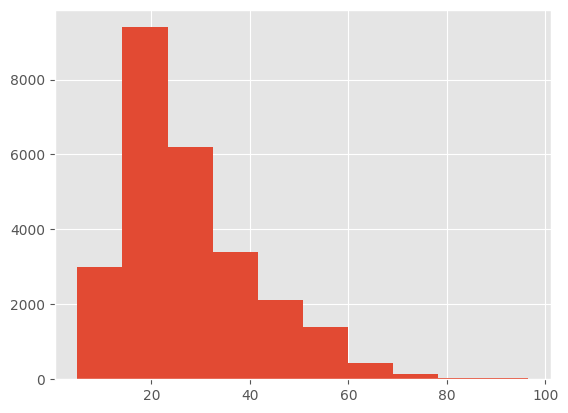

In [123]:
test_data['Energy'].hist()

In [124]:
ss_df.head()

,ID,Energy
0,2023-01-01 01:00:00_B_100,15.773698
1,2023-01-01 01:00:00_B_105,46.827715
2,2023-01-01 01:00:00_B_107,18.566225
3,2023-01-01 01:00:00_B_111,34.288705
4,2023-01-01 01:00:00_B_114,24.332797


In [126]:
test_data['ID'] = test_data['time'].astype('str') + '_' + test_data['bs']

In [127]:
test_data[['ID', 'Energy']]

,ID,Energy
3,2023-01-01 01:00:00_B_100,15.396199
8,2023-01-01 01:00:00_B_105,47.004387
10,2023-01-01 01:00:00_B_107,18.371328
15,2023-01-01 01:00:00_B_111,33.529045
18,2023-01-01 01:00:00_B_114,23.093496
...,...,...
118757,2023-01-08 00:00:00_B_786,24.381794
118761,2023-01-08 00:00:00_B_790,21.948481
118762,2023-01-08 00:00:00_B_791,18.718739
118763,2023-01-08 00:00:00_B_792,20.028330


In [128]:
ss_df = ss_df[['ID']]
ss_df = ss_df.merge(test_data[['ID', 'Energy']], on='ID', how='left')

In [129]:
ss_df.head()

,ID,Energy
0,2023-01-01 01:00:00_B_100,15.396199
1,2023-01-01 01:00:00_B_105,47.004387
2,2023-01-01 01:00:00_B_107,18.371328
3,2023-01-01 01:00:00_B_111,33.529045
4,2023-01-01 01:00:00_B_114,23.093496


In [130]:
ss_df.to_csv("base_model_submission.csv", index=False)